In [11]:
import pandas as pd
df = pd.read_csv("Bookings.csv")
df.head()

,Date,Time,Booking_ID,Booking_Status,Customer_ID,Vehicle_Type,Pickup_Location,Drop_Location,V_TAT,C_TAT,Canceled_Rides_by_Customer,Canceled_Rides_by_Driver,Incomplete_Rides,Incomplete_Rides_Reason,Booking_Value,Payment_Method,Ride_Distance,Driver_Ratings,Customer_Rating,Vehicle Images
0,26-07-2024 14:00,14:00:00,CNR7153255142,Canceled by Driver,CID713523,Prime Sedan,Tumkur Road,RT Nagar,NaN,NaN,NaN,Personal & Car related issue,NaN,NaN,444,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/14183/1...
1,25-07-2024 22:20,22:20:00,CNR2940424040,Success,CID225428,Bike,Magadi Road,Varthur,203.0,30.0,NaN,NaN,No,NaN,158,Cash,13,4.1,4.0,https://cdn-icons-png.flaticon.com/128/9983/99...
2,30-07-2024 19:59,19:59:00,CNR2982357879,Success,CID270156,Prime SUV,Sahakar Nagar,Varthur,238.0,130.0,NaN,NaN,No,NaN,386,UPI,40,4.2,4.8,https://cdn-icons-png.flaticon.com/128/9983/99...
3,22-07-2024 03:15,03:15:00,CNR2395710036,Canceled by Customer,CID581320,eBike,HSR Layout,Vijayanagar,NaN,NaN,Driver is not moving towards pickup location,NaN,NaN,NaN,384,NaN,0,NaN,NaN,https://cdn-icons-png.flaticon.com/128/6839/68...
4,02-07-2024 09:02,09:02:00,CNR1797421769,Success,CID939555,Mini,Rajajinagar,Chamarajpet,252.0,80.0,NaN,NaN,No,NaN,822,Credit Card,45,4.0,3.0,https://cdn-icons-png.flaticon.com/128/3202/32...


In [12]:
df['Date'] = pd.to_datetime(df['Date'])

C:\Users\ACER\AppData\Local\Temp\ipykernel_13096\2394721818.py:1: UserWarning: Parsing dates in %d-%m-%Y %H:%M format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  df['Date'] = pd.to_datetime(df['Date'])


In [13]:
numeric_col =  ['V_TAT', 'C_TAT', 'Booking_Value']
summary = df[numeric_col].describe().T
summary['medain'] = df[numeric_col].median()
summary['IQR'] = summary['75%'] - summary['25%']
summary

,count,mean,std,min,25%,50%,75%,max,medain,IQR
V_TAT,44271.0,171.323620,80.682293,35.0,98.0,168.0,238.0,308.0,168.0,140.0
C_TAT,44271.0,84.955275,35.959016,25.0,55.0,85.0,115.0,145.0,85.0,60.0
Booking_Value,71201.0,548.233901,535.399324,100.0,242.0,385.0,622.0,2999.0,385.0,380.0


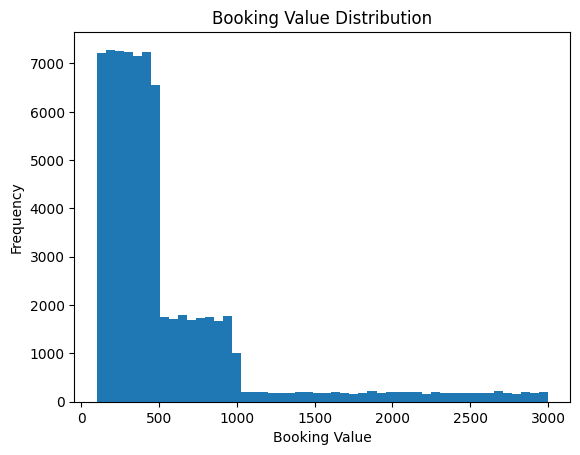

In [14]:
import matplotlib.pyplot as plt
plt.hist(df['Booking_Value'], bins=50)
plt.title("Booking Value Distribution")
plt.xlabel("Booking Value")
plt.ylabel("Frequency")
plt.show()

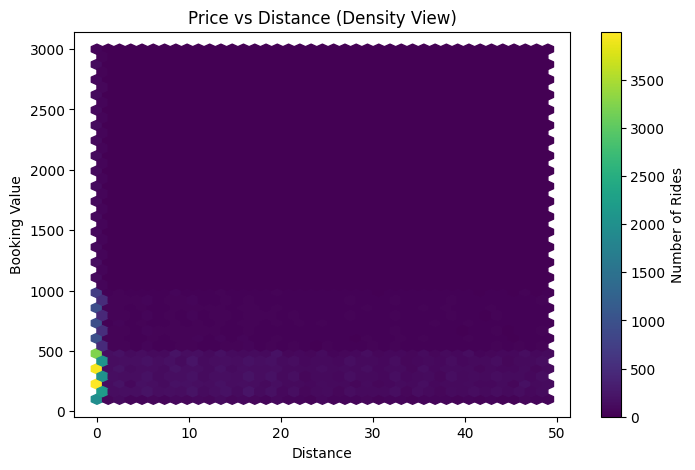

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
plt.hexbin(df["Ride_Distance"], df["Booking_Value"], gridsize=40)
plt.xlabel("Distance")
plt.ylabel("Booking Value")
plt.title("Price vs Distance (Density View)")
plt.colorbar(label="Number of Rides")
plt.show()

#this shows tht prices are inconsistent and concenterated at shorter distances

In [21]:
df.groupby("Canceled_Rides_by_Driver")["Booking_Value"].mean()


Canceled_Rides_by_Driver
Customer related issue                 546.155117
Customer was coughing/sick             549.076832
More than permitted people in there    560.106586
Personal & Car related issue           564.914588
Name: Booking_Value, dtype: float64

In [22]:
df.groupby("Canceled_Rides_by_Customer")["Booking_Value"].mean()

Canceled_Rides_by_Customer
AC is Not working                               537.216114
Change of plans                                 544.292035
Driver asked to cancel                          536.312804
Driver is not moving towards pickup location    575.241092
Wrong Address                                   530.439528
Name: Booking_Value, dtype: float64

In [23]:
df["Price_Bucket"] = pd.cut(
    df["Booking_Value"],
    bins=[0, 200, 500, 1000, df["Booking_Value"].max()],
    labels=["Low", "Medium", "High", "Very High"]
)

df.groupby("Price_Bucket")["Booking_Status"].value_counts(normalize=True)

C:\Users\ACER\AppData\Local\Temp\ipykernel_13096\2637810801.py:7: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby("Price_Bucket")["Booking_Status"].value_counts(normalize=True)


Price_Bucket  Booking_Status      
Low           Success                 0.624268
              Canceled by Driver      0.184069
              Canceled by Customer    0.095950
              Driver Not Found        0.095713
Medium        Success                 0.621404
              Canceled by Driver      0.174027
              Canceled by Customer    0.103765
              Driver Not Found        0.100805
High          Success                 0.624380
              Canceled by Driver      0.183456
              Canceled by Customer    0.098861
              Driver Not Found        0.093302
Very High     Success                 0.613018
              Canceled by Driver      0.184756
              Canceled by Customer    0.103432
              Driver Not Found        0.098794
Name: proportion, dtype: float64

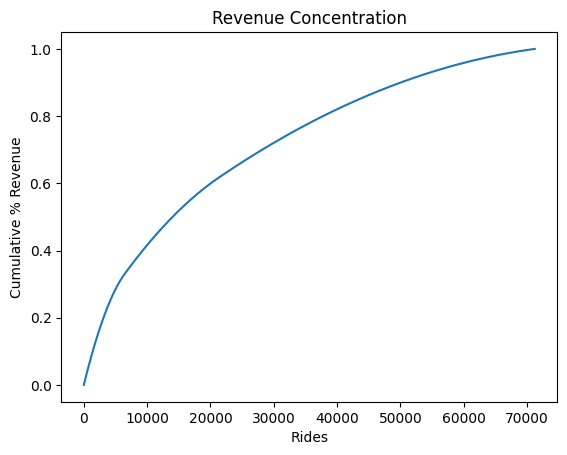

In [ ]:
df_sorted = df.sort_values("Booking_Value", ascending=False)

df_sorted["cumulative_revenue"] = df_sorted["Booking_Value"].cumsum()
df_sorted["cumulative_percent"] = df_sorted["cumulative_revenue"] / df["Booking_Value"].sum()

plt.plot(df_sorted["cumulative_percent"].values)
plt.title("Revenue Concentration")
plt.xlabel("Rides")
plt.ylabel("Cumulative % Revenue")
plt.show()

#revenue accumulates as we include rides from highest to lowest value 

C:\Users\ACER\AppData\Local\Temp\ipykernel_13096\3700356482.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


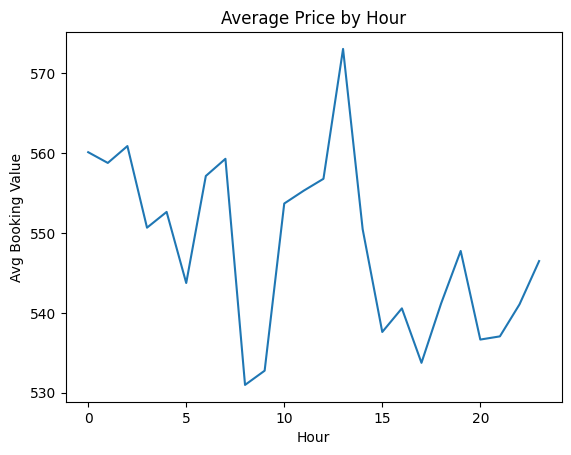

In [25]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

df.groupby("Hour")["Booking_Value"].mean()

plt.plot(df.groupby("Hour")["Booking_Value"].mean())
plt.title("Average Price by Hour")
plt.xlabel("Hour")
plt.ylabel("Avg Booking Value")
plt.show()